# Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import joblib

# Importing the Dataset

In [2]:
df = pd.read_csv('pumicestone-v3.csv', dtype=str, low_memory=False)

# EDA

In [3]:
df.head()

,Timestamp,Record number,Average Water Speed,Average Water Speed [quality],Average Water Direction,Average Water Direction [quality],Chlorophyll,Chlorophyll [quality],Temperature,Temperature [quality],...,Dissolved Oxygen (%Saturation),Dissolved Oxygen (%Saturation) [quality],pH,pH [quality],Salinity,Salinity [quality],Specific Conductance,Specific Conductance [quality],Turbidity,Turbidity [quality]
0,Units,NaN,cm/s,NaN,degrees,NaN,ug/L,NaN,DegreesC,NaN,...,%,NaN,PH,NaN,ppm,NaN,mS/cm,NaN,FNU,NaN
1,2023-08-04 23:00:00,1468,4.834,NaN,73.484,NaN,1.621,NaN,20.018,NaN,...,101.175,NaN,8.176,NaN,35.215,NaN,53.262,NaN,2.068,NaN
2,2023-08-04 23:30:00,1469,2.544,NaN,106.424,NaN,1.959,NaN,19.986,NaN,...,100.884,NaN,8.175,NaN,35.209,NaN,53.254,NaN,1.994,NaN
3,2023-08-04 23:00:00,1470,1.26,NaN,156.755,NaN,1.62,NaN,20.001,NaN,...,100.571,NaN,8.171,NaN,35.207,NaN,53.252,NaN,2.03,NaN
4,2023-08-04 23:30:00,1471,0.76,NaN,281.754,NaN,1.761,NaN,19.983,NaN,...,100.398,NaN,8.171,NaN,35.211,NaN,53.257,NaN,1.973,NaN


In [4]:
df.isnull().sum()

Timestamp                                       0
Record number                                   1
Average Water Speed                          1082
Average Water Speed [quality]               68159
Average Water Direction                         1
Average Water Direction [quality]           68159
Chlorophyll                                  1710
Chlorophyll [quality]                        1934
Temperature                                  9218
Temperature [quality]                        9399
Dissolved Oxygen                             4315
Dissolved Oxygen [quality]                   4540
Dissolved Oxygen (%Saturation)               6340
Dissolved Oxygen (%Saturation) [quality]     6542
pH                                           1127
pH [quality]                                 1352
Salinity                                     4132
Salinity [quality]                           4357
Specific Conductance                         1440
Specific Conductance [quality]               1665


In [5]:
df = df.drop(columns=[col for col in df.columns if "[quality]" in col])

In [6]:
df.isnull().sum()

Timestamp                            0
Record number                        1
Average Water Speed               1082
Average Water Direction              1
Chlorophyll                       1710
Temperature                       9218
Dissolved Oxygen                  4315
Dissolved Oxygen (%Saturation)    6340
pH                                1127
Salinity                          4132
Specific Conductance              1440
Turbidity                         7970
dtype: int64

In [7]:
#converting to numeric columns where required:
numeric_cols = df.columns.drop("Timestamp")
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

In [8]:
df.isnull().sum()

Timestamp                            0
Record number                        1
Average Water Speed               1083
Average Water Direction              2
Chlorophyll                       1711
Temperature                       9219
Dissolved Oxygen                  4316
Dissolved Oxygen (%Saturation)    6341
pH                                1128
Salinity                          4133
Specific Conductance              1441
Turbidity                         7971
dtype: int64

### Filling the dataset based on time

In [9]:
df = df[df["Timestamp"] != "Units"]
df = df[df["Timestamp"].notna()]

df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values('Timestamp')


In [10]:
df = df.fillna(method='bfill').fillna(method='ffill')
df = df.reset_index()


C:\Users\shreya\AppData\Local\Temp\ipykernel_9284\3388108609.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill').fillna(method='ffill')


In [11]:
df.isnull().sum()

index                             0
Timestamp                         0
Record number                     0
Average Water Speed               0
Average Water Direction           0
Chlorophyll                       0
Temperature                       0
Dissolved Oxygen                  0
Dissolved Oxygen (%Saturation)    0
pH                                0
Salinity                          0
Specific Conductance              0
Turbidity                         0
dtype: int64

# Calculating WQI based on WHO standards and adding the WQI and WQI class column to our dataset

In [12]:
# BIS Standards (IS 10500:2012)
standards = {
    'pH': 8.5,
    'Turbidity': 5,
    'Dissolved Oxygen (%Saturation)': 80,
    'Temperature': 30,
    'Salinity': 1,
    'Specific Conductance': 1000,
    'Chlorophyll': 5
}

# Ideal values (Vi)
ideals = {
    'pH': 7,
    'Turbidity': 0,
    'Dissolved Oxygen (%Saturation)': 100,
    'Temperature': 25,
    'Salinity': 0,
    'Specific Conductance': 0,
    'Chlorophyll': 0
}

# ------------------------------
# COMPUTE UNIT WEIGHTS (Wi)
# ------------------------------
def compute_weights(standards):
    inv_sum = sum([1/s for s in standards.values()])
    k = 1 / inv_sum
    weights = {param: k / s for param, s in standards.items()}
    return weights

weights = compute_weights(standards)

# ------------------------------
# QUALITY RATING (Qi)
# ------------------------------
def quality_rating(param, value):
    Si = standards[param]
    Vi = ideals[param]
    
    # If missing or zero
    if value is None or value == 0:
        return 0
    
    Qi = ((value - Vi) / (Si - Vi)) * 100
    
    # Clamp between 0 and 100
    Qi = max(0, min(Qi, 100))
    
    return Qi

# ------------------------------
# CALCULATE WQI
# ------------------------------
def compute_wqi(row):
    total = 0
    total_w = 0
    
    for param in standards:
        Wi = weights[param]
        Qi = quality_rating(param, row[param])
        
        total += Wi * Qi
        total_w += Wi
    
    return total / total_w

# ------------------------------
# CLASSIFY WQI
# ------------------------------
def classify_wqi(wqi):
    if wqi > 75:
        return 'Excellent'
    elif wqi > 50:
        return 'Good'
    elif wqi > 25:
        return 'Fair'
    else:
        return 'Poor'

# ------------------------------
# APPLY ON DF
# ------------------------------
df["WQI"] = df.apply(compute_wqi, axis=1)
df["WQI_Class"] = df["WQI"].apply(classify_wqi)

df.to_csv("wqi_bis_results.csv", index=False)

print(df[['WQI', 'WQI_Class']].head())


         WQI  WQI_Class
0  79.249862  Excellent
1  79.125082  Excellent
2  78.943552  Excellent
3  80.105628  Excellent
4  79.919833  Excellent


In [13]:
df.head()

,index,Timestamp,Record number,Average Water Speed,Average Water Direction,Chlorophyll,Temperature,Dissolved Oxygen,Dissolved Oxygen (%Saturation),pH,Salinity,Specific Conductance,Turbidity,WQI,WQI_Class
0,1,2023-08-04 23:00:00,1468.0,4.834,73.484,1.621,20.018,7.472,101.175,8.176,35.215,53.262,2.068,79.249862,Excellent
1,3,2023-08-04 23:00:00,1470.0,1.260,156.755,1.620,20.001,7.430,100.571,8.171,35.207,53.252,2.030,79.125082,Excellent
2,5,2023-08-04 23:00:00,1472.0,3.397,244.637,1.635,19.986,7.429,100.538,8.171,35.208,53.253,1.944,78.943552,Excellent
3,6,2023-08-04 23:00:00,1473.0,1.596,100.271,1.935,19.834,7.430,100.293,8.158,35.255,53.315,2.124,80.105628,Excellent
4,2,2023-08-04 23:30:00,1469.0,2.544,106.424,1.959,19.986,7.455,100.884,8.175,35.209,53.254,1.994,79.919833,Excellent


In [14]:
# Assuming your classification column is 'WQI_class'
category_counts = df['WQI_Class'].value_counts()

print(category_counts)


WQI_Class
Excellent    65308
Good          2493
Poor           323
Fair            34
Name: count, dtype: int64


In [15]:
features = ['Dissolved Oxygen (%Saturation)','pH','Turbidity','Temperature',
            'Salinity','Specific Conductance','Chlorophyll']
X = df[features].values
y = df['WQI_Class']

# Splitting into Training and Test set

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [17]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Model selction using ML

In [19]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
classifiers = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "SVM": Pipeline([
        ('scale', StandardScaler()),
        ('svc', SVC(kernel='rbf', random_state=42, class_weight='balanced'))
    ]),
    "KNN": Pipeline([
        ('scale', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=5))
    ])
}

# Train and evaluate each classifier
results = {}
for name, clf in classifiers.items():
    clf.fit(X_train_res, y_train_res)
    y_pred = clf.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"=== {name} ===")
    print(f"Accuracy: {acc:.4f}")
    print("Classification Report:\n", classification_report(y_test, y_pred, digits=4))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\n")

# Summary table
summary_df = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy']).sort_values(by='Accuracy', ascending=False)
print("Summary of accuracies:\n", summary_df)


=== Random Forest ===
Accuracy: 0.9965
Classification Report:
               precision    recall  f1-score   support

   Excellent     0.9993    0.9971    0.9982     13062
        Fair     0.8750    1.0000    0.9333         7
        Good     0.9279    0.9800    0.9532       499
        Poor     1.0000    1.0000    1.0000        64

    accuracy                         0.9965     13632
   macro avg     0.9506    0.9943    0.9712     13632
weighted avg     0.9966    0.9965    0.9965     13632

Confusion Matrix:
 [[13024     0    38     0]
 [    0     7     0     0]
 [    9     1   489     0]
 [    0     0     0    64]]


=== Decision Tree ===
Accuracy: 0.9951
Classification Report:
               precision    recall  f1-score   support

   Excellent     0.9988    0.9962    0.9975     13062
        Fair     0.8750    1.0000    0.9333         7
        Good     0.9060    0.9659    0.9350       499
        Poor     1.0000    1.0000    1.0000        64

    accuracy                         

In [20]:
joblib.dump(clf, "wqi_classifier.pkl")

['wqi_classifier.pkl']

In [22]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [33]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

# Training An isolation Forest Model to detect Anomaly and ensure better Predictions:

In [ ]:
from sklearn.ensemble import IsolationForest


# Train Isolation Forest on scaled normal patterns
iso = IsolationForest(
    n_estimators=300,
    contamination=0.015,  # ~1.5% anomalies expected
    random_state=42
)
iso.fit(X_scaled)

# Predict anomaly flags and anomaly scores
iso_scores = iso.decision_function(X_scaled)  # higher = normal, lower = anomaly
iso_flags = iso.predict(X_scaled)  # -1 = anomaly, 1 = normal

df["Anomaly"] = (iso_flags == -1).astype(int)
df["Anomaly_Score"] = iso_scores

#  New Hybrid Logic (Option C)
def hybrid_model(row):
    if row["Anomaly"] == 0:
        return row["WQI_Class"]  # keep Excellent normally
    else:
        score = row["Anomaly_Score"]
        if score > -0.02:
            return "Good"
        elif score > -0.08:
            return "Fair"
        else:
            return "Poor"


df["Hybrid_Prediction"] = df.apply(hybrid_model, axis=1)

print(df["Anomaly"].value_counts())
print(df["Hybrid_Prediction"].value_counts())

# Save model
joblib.dump(iso, "isoforest.pkl")
print("Isolation Forest + Hybrid classification saved successfully!")


Anomaly
0    67135
1     1023
Name: count, dtype: int64
Hybrid_Prediction
Excellent    64647
Good          2797
Fair           667
Poor            47
Name: count, dtype: int64
Isolation Forest + Hybrid classification saved successfully!


##### Results:

In [24]:
print(pd.crosstab(df['WQI_Class'], df['Anomaly']))


Anomaly        0    1
WQI_Class            
Excellent  64647  661
Fair          10   24
Good        2431   62
Poor          47  276


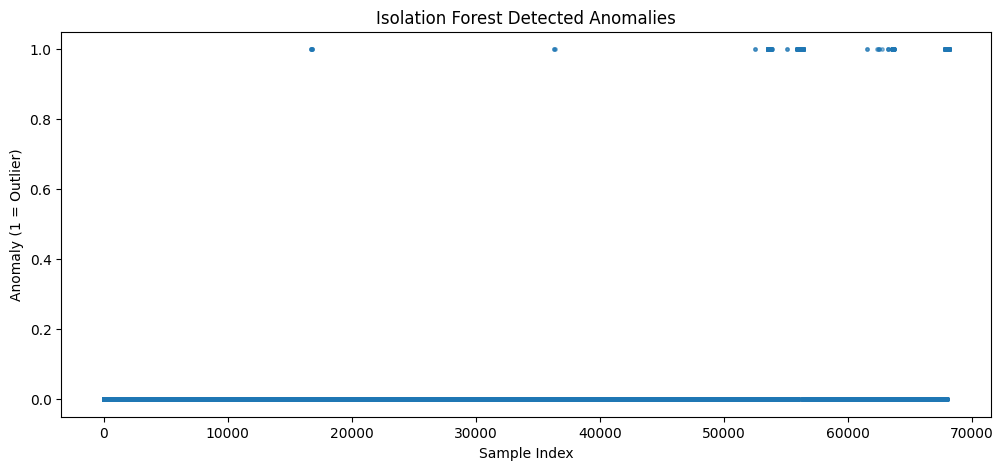

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.scatter(range(len(df)), df['Anomaly'], s=6, alpha=0.5)
plt.title("Isolation Forest Detected Anomalies")
plt.xlabel("Sample Index")
plt.ylabel("Anomaly (1 = Outlier)")
plt.show()

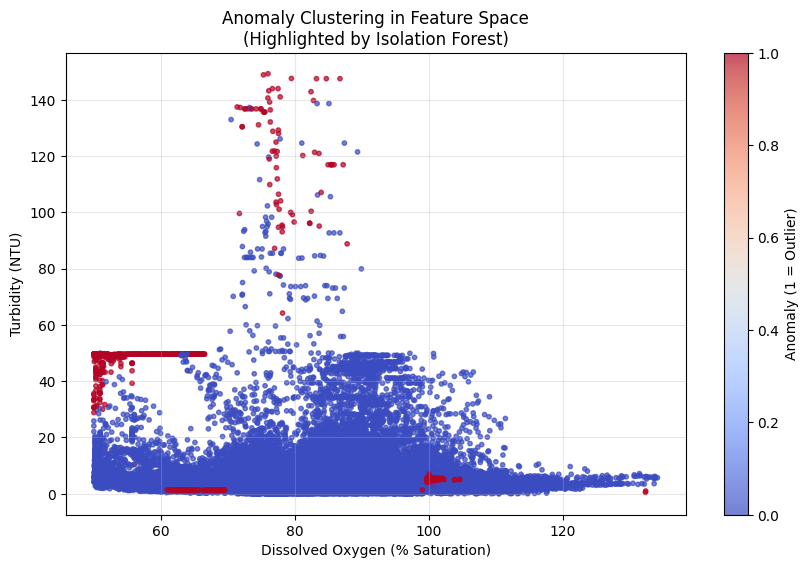

In [26]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df['Dissolved Oxygen (%Saturation)'],
    df['Turbidity'],
    c=df['Anomaly'],
    cmap='coolwarm',
    s=10,
    alpha=0.7
)

plt.xlabel("Dissolved Oxygen (% Saturation)")
plt.ylabel("Turbidity (NTU)")
plt.title("Anomaly Clustering in Feature Space\n(Highlighted by Isolation Forest)")
plt.colorbar(scatter, label="Anomaly (1 = Outlier)")
plt.grid(alpha=0.3)
plt.show()


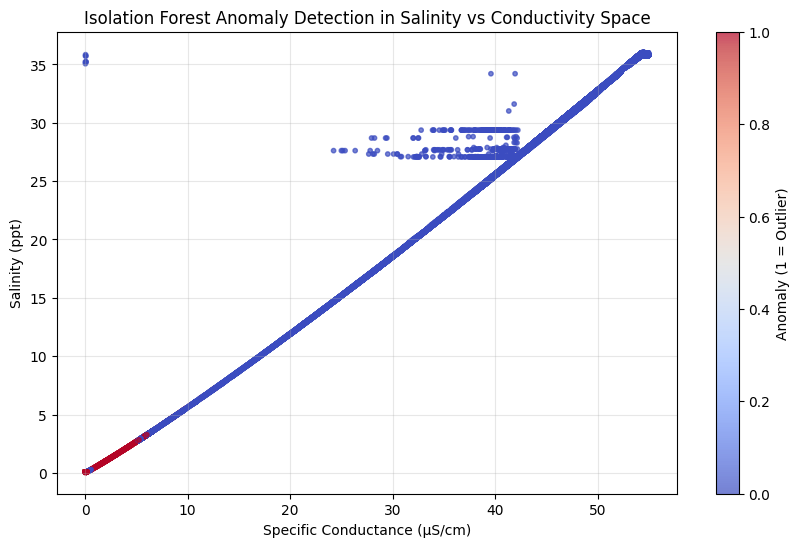

In [27]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df['Specific Conductance'],
    df['Salinity'],
    c=df['Anomaly'],
    cmap='coolwarm',
    s=10,
    alpha=0.7
)

plt.xlabel("Specific Conductance (µS/cm)")
plt.ylabel("Salinity (ppt)")
plt.title("Isolation Forest Anomaly Detection in Salinity vs Conductivity Space")
plt.colorbar(scatter, label="Anomaly (1 = Outlier)")
plt.grid(alpha=0.3)
plt.show()


### Hybrid Classification Testing

In [32]:


# Load saved models
clf = joblib.load("wqi_classifier.pkl")
scaler = joblib.load("scaler.pkl")
iso = joblib.load("isoforest.pkl")  # Updated file name

def hybrid_predict(features):
    x = np.array(features).reshape(1, -1)

    # Classifier tries to classify
    class_pred = clf.predict(x)[0]

    # Isolation Forest anomaly score
    x_scaled = scaler.transform(x)
    score = iso.decision_function(x_scaled)[0]
    is_anomaly = (iso.predict(x_scaled)[0] == -1)

    # Hybrid logic (score-based water quality)
    if not is_anomaly:
        hybrid_pred = class_pred  # Excellent normally
    else:
        if score > -0.02:
            hybrid_pred = "Good"
        elif score > -0.08:
            hybrid_pred = "Fair"
        else:
            hybrid_pred = "Poor"


    return class_pred, is_anomaly, score, hybrid_pred


# -------------------------
# TEST CASES
# -------------------------
test_cases = {
    # Good: slightly degraded but still acceptable
    "Excellent Water 1": [95, 7.6, 1.5, 22, 0.3, 200, 2],
    "Good Water 1": [75, 7.2, 5, 25, 0.8, 400, 6],
    "Fair Water 1": [50, 6.8, 15, 28, 1.5, 900, 15],
    "Poor Water 3": [12, 5.8, 50, 33, 4.2, 2500, 55]

}

for name, features in test_cases.items():
    class_pred, anomaly, score, hybrid = hybrid_predict(features)
    print(f"\n{name}")
    print("-----------------------")
    print(f"Classifier Prediction: {class_pred}")
    print(f"Anomaly Flag: {anomaly}")
    print(f"Anomaly Score: {score:.4f}")
    print(f"Hybrid Final Output: {hybrid}")



Excellent Water 1
-----------------------
Classifier Prediction: Excellent
Anomaly Flag: False
Anomaly Score: 0.0412
Hybrid Final Output: Excellent

Good Water 1
-----------------------
Classifier Prediction: Excellent
Anomaly Flag: False
Anomaly Score: 0.0123
Hybrid Final Output: Excellent

Fair Water 1
-----------------------
Classifier Prediction: Excellent
Anomaly Flag: True
Anomaly Score: -0.0628
Hybrid Final Output: Fair

Poor Water 3
-----------------------
Classifier Prediction: Excellent
Anomaly Flag: True
Anomaly Score: -0.1048
Hybrid Final Output: Poor


### Results and Accuracy

#### Plain Classification Model

In [30]:
y_pred_test = clf.predict(X_test)

clf_acc = accuracy_score(y_test, y_pred_test)
print(f"Classifier Test Accuracy: {clf_acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test))


Classifier Test Accuracy: 0.9826

Classification Report:
              precision    recall  f1-score   support

   Excellent       1.00      0.98      0.99     13062
        Fair       0.86      0.86      0.86         7
        Good       0.69      0.97      0.80       499
        Poor       1.00      1.00      1.00        64

    accuracy                           0.98     13632
   macro avg       0.89      0.95      0.91     13632
weighted avg       0.99      0.98      0.98     13632



#### Hybrid Model

In [31]:
hybrid_acc = accuracy_score(df["WQI_Class"], df["Hybrid_Prediction"])
print(f"Hybrid Model Overall Accuracy: {hybrid_acc:.4f}")

print("\nHybrid Classification Report:")
print(classification_report(df["WQI_Class"], df["Hybrid_Prediction"]))


Hybrid Model Overall Accuracy: 0.9855

Hybrid Classification Report:
              precision    recall  f1-score   support

   Excellent       1.00      0.99      0.99     65308
        Fair       0.05      1.00      0.10        34
        Good       0.87      0.98      0.92      2493
        Poor       1.00      0.15      0.25       323

    accuracy                           0.99     68158
   macro avg       0.73      0.78      0.57     68158
weighted avg       0.99      0.99      0.99     68158

